In [1]:
# import bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# funcoes sklearn
from sklearn.model_selection import train_test_split # separa base de dados em um conjunto treinamento e outro testes
from sklearn.preprocessing import StandardScaler # faz magnitude ser semelhante
from sklearn.neighbors import KNeighborsClassifier # versao para classificacao
from sklearn.metrics import confusion_matrix # calcula matriz de confusao
from sklearn.metrics import accuracy_score # calcula a acuracia
from sklearn.metrics import ConfusionMatrixDisplay # produz grafico com a matriz de confusao

In [3]:
# leitura de dados
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# informacoes basicas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# descricao de dados
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


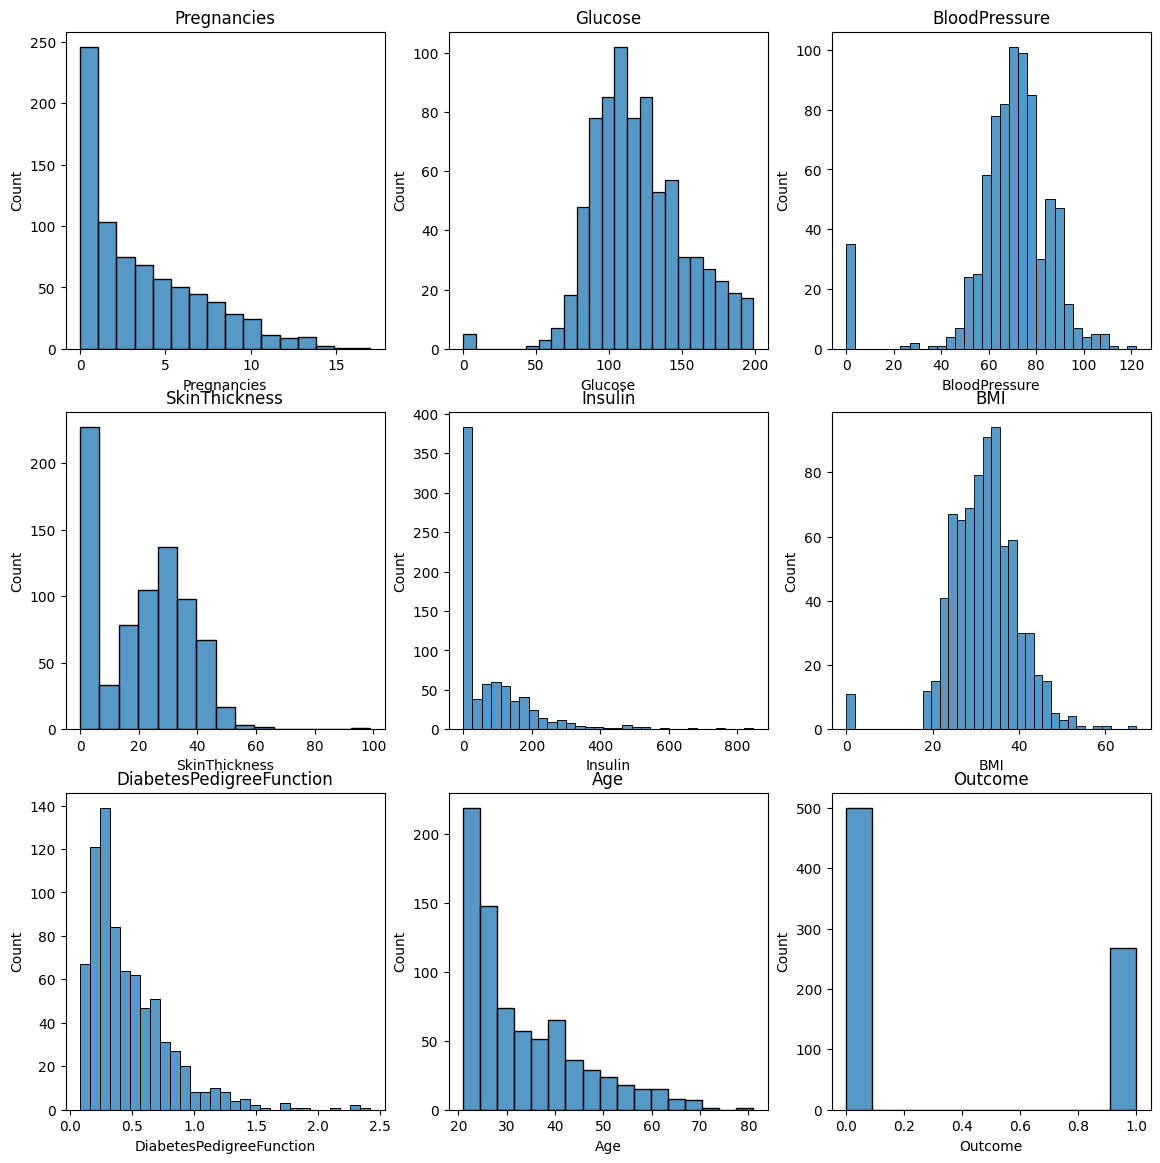

In [6]:
# padronizando valores das colunas para terem a mesma escala de grandeza
fig, axes = plt.subplots(nrows = 3, ncols = 3)
axes = axes.flatten()
fig.set_size_inches(14, 14)

for ax, col in zip(axes, df.columns):
  sns.histplot(df[col], ax = ax)
  ax.set_title(col)

In [7]:
# Separacao dos conjuntos de treino e teste
X = df.drop(columns=['Outcome'])
y = df['Outcome']

x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=101)

# x usara somente variaveis independentes (remove-se outcome, ja que ela e a target, ela precisa ser definida com as informacoes contidas)
# coluna target e o y (outcome e seus valores)
# test size pega 30 porcento das amostras e separar para teste
# random state e a semente aleatoria (utiliza-se para resultados serem reprodutiveis)
# sem random state, cada resposta sera diferente
# sempre na ordem valor de treino- valor de teste

In [8]:
# padronizacao das variaveis
x_treino.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,537.000000,537.000000,537.000000,537.000000,537.000000,537.000000,537.000000,537.000000
mean,3.780261,120.770950,69.588454,20.476723,81.487896,32.182123,0.476709,33.312849
std,3.335715,31.800299,18.694423,16.206685,116.361170,7.872488,0.314891,11.988290
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.085000,21.000000
25%,1.000000,100.000000,64.000000,0.000000,0.000000,27.500000,0.245000,24.000000
50%,3.000000,116.000000,72.000000,23.000000,40.000000,32.300000,0.389000,29.000000
75%,6.000000,142.000000,80.000000,32.000000,126.000000,36.600000,0.645000,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.137000,72.000000


In [9]:
scaler = StandardScaler()
scaler = scaler.fit(x_treino) # equivale ao treinamento do modelo (sempre faca fit com modelo de treino)
# se usar fit em testes, que usam dados futuros, os dados serao corrompidos, portanto, nao os use em modelos de fit, pois ele foi treinado com oq ja acontece

x_treino = scaler.transform(x_treino)
x_teste = scaler.transform(x_teste)

In [10]:
x_treino

array([[ 0.36600141,  0.16458732,  0.45036901, ..., -0.32829909,
        -0.11986593,  0.55832698],
       [-1.13432499,  0.79409863,  0.66453607, ...,  1.0575606 ,
         4.14590502,  0.892297  ],
       [ 0.36600141, -0.3704973 , -0.40629925, ...,  0.45998808,
         0.11853409, -0.6940606 ],
       ...,
       [-0.83425971, -0.05574164, -1.37005104, ...,  0.42184515,
        -0.62527396, -0.6940606 ],
       [ 0.36600141, -0.18164391,  0.34328548, ..., -0.12487014,
        -0.42501795,  0.892297  ],
       [ 1.56626254,  0.29048958,  0.02203488, ...,  0.25655913,
         0.55719012,  0.9757895 ]])

In [11]:
# treinamento de modelo
clf = KNeighborsClassifier()
clf.fit(x_treino, y_treino)
# e rapido porque por enquanto, so armazena os valores de treino na memoria

KNeighborsClassifier()

In [12]:
# previsoes com o modelo (calcula todas as distancias)
pred = clf.predict(x_teste)
pred

array([1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1])

In [13]:
# Avaliacao do modelo
matriz_confusao = confusion_matrix(pred, y_teste)
matriz_confusao
# esses sao os valores de falsos positivos, verdadeiros positivos, etc..

array([[130,  35],
       [ 20,  46]])

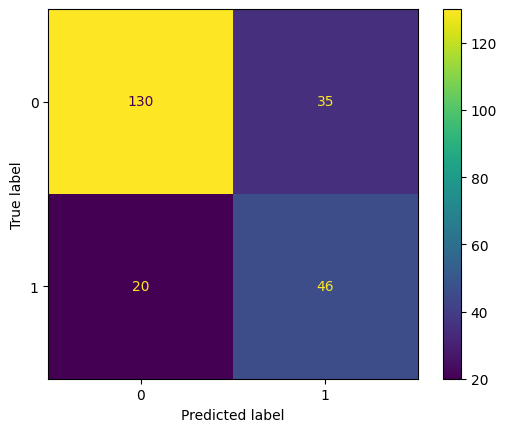

In [14]:
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao,
                              display_labels=clf.classes_)
disp.plot()

# disse que 130 nao eram e realmente nao eram (amarelo) - verdadeiros negativos
# disse que 35 eram diabeticos mas nao eram (roxo) - falsos positivos
# disse que 20 nao eram diabeticos, mas eram (rosa) - falsos negativos
# disse que 46 eram diabeticos e realmente eram - verdadeiros positivos

In [15]:
print(accuracy_score(pred, y_teste))
# tem uma acuracia de 76 porcento

0.7619047619047619


In [16]:
# percentual de pacientes que sao diabeticos no data set (35%)
y_teste.sum() / len(y_teste)

np.float64(0.35064935064935066)

In [17]:
# percentual de pacientes que nao sao diabeticos no data set (65%)
1 - (y_teste.sum() / len(y_teste))

np.float64(0.6493506493506493)

In [18]:
# se considerar somente a acuracia e ele verificasse somente os que nao sao, ele ainda acertaria 65% e por isso, nao pode confiar somente na acuracia